In [4]:
import pandas as pd
import numpy as np

# load dataset
df = pd.read_csv(r"C:\Users\devso\causal-ml-project\data\raw\hillstrom.csv")

df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  str    
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  str    
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  str    
 8   segment          64000 non-null  str    
 9   visit            64000 non-null  int64  
 10  conversion       64000 non-null  int64  
 11  spend            64000 non-null  float64
dtypes: float64(2), int64(6), str(4)
memory usage: 5.9 MB


,recency,history,mens,womens,newbie,visit,conversion,spend
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,5.763734,242.085656,0.551031,0.549719,0.502250,0.146781,0.009031,1.050908
std,3.507592,256.158608,0.497393,0.497526,0.499999,0.353890,0.094604,15.036448
min,1.000000,29.990000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,64.660000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,158.110000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,9.000000,325.657500,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,12.000000,3345.930000,1.000000,1.000000,1.000000,1.000000,1.000000,499.000000


In [7]:
df['segment'].value_counts(normalize=True)

segment
Womens E-Mail    0.334172
Mens E-Mail      0.332922
No E-Mail        0.332906
Name: proportion, dtype: float64

In [8]:
df['treatment'] = df['segment'].apply(lambda x: 0 if x == 'No E-Mail' else 1)

df['treatment'].value_counts()

treatment
1    42694
0    21306
Name: count, dtype: int64

In [9]:
df['conversion'].value_counts(normalize=True)

conversion
0    0.990969
1    0.009031
Name: proportion, dtype: float64

In [10]:
df.groupby('treatment')['conversion'].mean()

treatment
0    0.005726
1    0.010681
Name: conversion, dtype: float64

In [11]:
df.groupby('treatment')[['recency', 'history']].mean()

,recency,history
treatment,,
0,5.749695,240.882653
1,5.770741,242.686002


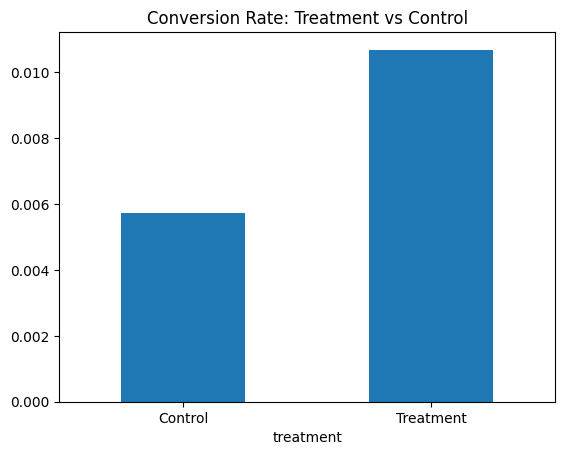

In [12]:
import matplotlib.pyplot as plt

df.groupby('treatment')['conversion'].mean().plot(kind='bar')
plt.title("Conversion Rate: Treatment vs Control")
plt.xticks([0,1], ['Control', 'Treatment'], rotation=0)
plt.show()